# 06. Modele ML predictive - Pret energie Spania

**Sesiunea 2 din Etapa II: Dezvoltarea Modelelor Predictive (Machine Learning)**

**Scop:** anticiparea pretului orar al energiei electrice (`price actual`) in piata spaniola, pentru perioada 2015-2018. Aceasta sesiune introduce **doua inovatii metodologice** fata de Sesiunea 1 (USA):

1. **Optuna** in loc de GridSearchCV - Bayesian optimization care e de 5-10x mai eficient pentru spatii mari de hyperparametri.
2. **SHAP values** pentru explicabilitate - cu 80 features, intelegerea contributiei fiecarei variabile e critica.

**Algoritmi comparati:**
1. **LinearRegression** - baseline.
2. **Ridge** si **Lasso** - regularizare L2 si L1 (importanta cu 80 features).
3. **RandomForest** - ansamblu de arbori.
4. **XGBoost** (default + Optuna-tuned) - gradient boosting.
5. **LSTM** - retea recurenta cu memorie.

**Prophet exclus** - in Sesiunea 1 (USA) am demonstrat ca esueaza pe acest tip de date energetice agregate.

**Validare:** TimeSeriesSplit cu 5 folduri cronologice. Metrici: RMSE, MAE, R^2, MAPE.

**Particularitati Spania**: 80 features (28 surse generare + meteo Madrid + lag-uri + rolling), volatilitate ridicata (0-100+ EUR/MWh, ocazional valori negative), 35.000 randuri.

## Setup

In [1]:
import sys, time
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing.preprocessing import chronological_split, scale_features
from src.ml_models.predictors import (
    evaluate, train_linear, train_random_forest, train_xgboost,
    train_lstm, predict_lstm,
    time_series_cv, tune_with_optuna, compute_shap_values,
    save_model, get_feature_importance,
    ModelResult,
)
from src.utils.config_loader import load_config
from src.utils.plotting import setup_style, PALETA

setup_style()
warnings.filterwarnings("ignore")

cfg = load_config()
P_CFG = cfg["preprocessing"]
print(f"Test size: {P_CFG['test_size']}, Validation size: {P_CFG['validation_size']}")

Test size: 0.2, Validation size: 0.1


## 1. Incarcare date procesate

Datele Spania (rezultate din pipeline-urile 04 si 04b) sunt deja salvate ca parquet. Includ 80 features per inregistrare.

In [2]:
parquet_path = PROJECT_ROOT / "data" / "processed" / "pret_spania_features.parquet"
df = pd.read_parquet(parquet_path)
print(f"Shape: {df.shape}")
print(f"Range: {df.index.min()} -> {df.index.max()}")
print(f"Target: 'price actual'")
print(f"Numar features: {df.shape[1] - 1}")
print(f"\nPrimele coloane: {list(df.columns[:10])}")
print(f"\nStatistici target:")
print(df['price actual'].describe().round(2))

Shape: (34896, 79)
Range: 2015-01-07 23:00:00 -> 2018-12-31 22:00:00
Target: 'price actual'
Numar features: 78

Primele coloane: ['generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage consumption']

Statistici target:
count    34896.00
mean        57.83
std         14.20
min          9.33
25%         49.31
50%         57.97
75%         67.97
max        116.80
Name: price actual, dtype: float64


## 2. Selectie regim de rulare: DEMO sau FULL

In **demo**: parametrii redusi pentru viteza (~30 secunde total).
In **full**: parametrii completi pentru rezultate finale (~1-2 ore CPU).

In [3]:
# === COMUTATOR REGIM RULARE ===
MODE = "demo"  # "demo" sau "full"

PARAMS = {
    "demo": {
        # LSTM
        "N_TRAIN_LSTM": 1000, "N_VAL_LSTM": 300, "N_TEST_LSTM": 500,
        "LSTM_UNITS": 16, "LSTM_EPOCHS": 3, "LSTM_BATCH": 64,
        # Optuna
        "OPTUNA_TRIALS": 5, "OPTUNA_SPLITS": 3,
        "N_TUNE": 2000,
        # SHAP
        "SHAP_SAMPLES": 200,
        # TimeSeriesSplit CV
        "N_CV": 5000, "CV_SPLITS": 3,
        # Modele clasice
        "RF_ESTIMATORS": 30, "RF_DEPTH": 10,
        "XGB_ESTIMATORS": 100, "XGB_DEPTH": 6,
    },
    "full": {
        "N_TRAIN_LSTM": 15000, "N_VAL_LSTM": 2000, "N_TEST_LSTM": 4000,
        "LSTM_UNITS": 48, "LSTM_EPOCHS": 15, "LSTM_BATCH": 256,
        "OPTUNA_TRIALS": 50, "OPTUNA_SPLITS": 3,
        "N_TUNE": 15000,
        "SHAP_SAMPLES": 1000,
        "N_CV": 20000, "CV_SPLITS": 5,
        "RF_ESTIMATORS": 200, "RF_DEPTH": None,
        "XGB_ESTIMATORS": 300, "XGB_DEPTH": 6,
    },
}

P = PARAMS[MODE]
print(f"Mod activ: '{MODE}'")
print(f"  Optuna: {P['OPTUNA_TRIALS']} trials x {P['OPTUNA_SPLITS']} folduri")
print(f"  LSTM: train={P['N_TRAIN_LSTM']}, epochs={P['LSTM_EPOCHS']}")
print(f"  SHAP: {P['SHAP_SAMPLES']} samples")

Mod activ: 'demo'
  Optuna: 5 trials x 3 folduri
  LSTM: train=1000, epochs=3
  SHAP: 200 samples


## 3. Split cronologic + scaler

Cu 80 features, scalarea e CRITICA pentru modelele liniare regularizate (Ridge, Lasso) si pentru LSTM. Fara scalare, features cu scale mari (cum e price-ul lag-uit) ar domina absolut.

In [4]:
sp = chronological_split(
    df, target="price actual",
    test_size=P_CFG["test_size"],
    validation_size=P_CFG["validation_size"],
)

print(f"Train: {sp['X_train'].shape}, perioada: {sp['X_train'].index.min().date()} -> {sp['X_train'].index.max().date()}")
print(f"Val:   {sp['X_val'].shape}, perioada: {sp['X_val'].index.min().date()} -> {sp['X_val'].index.max().date()}")
print(f"Test:  {sp['X_test'].shape}, perioada: {sp['X_test'].index.min().date()} -> {sp['X_test'].index.max().date()}")

Xt, Xv, Xs, scaler = scale_features(sp['X_train'], sp['X_val'], sp['X_test'], method='standard')
yt, yv, ys = sp['y_train'], sp['y_val'], sp['y_test']

print(f"\nDupa scalare (StandardScaler, fit doar pe train):")
print(f"  Train mean ~0, std ~1: {Xt.iloc[:, 0].mean():.3f}, {Xt.iloc[:, 0].std():.3f}")

Train: (24428, 78), perioada: 2015-01-07 -> 2017-10-21
Val:   (3489, 78), perioada: 2017-10-21 -> 2018-03-16
Test:  (6979, 78), perioada: 2018-03-16 -> 2018-12-31

Dupa scalare (StandardScaler, fit doar pe train):
  Train mean ~0, std ~1: -0.000, 1.000


## 4. Antrenare modele clasice (Linear, Ridge, Lasso, RF, XGBoost)

### Concepte noi pentru Spania - regularizarea

Cu 80 features, modelele liniare clasice (LinearRegression) sunt expuse la **multicoliniaritate** (multe features sunt corelate intre ele - de exemplu, suma generarii diferitelor surse e aproape egala cu cererea totala).

**Ridge (L2 regularization)** adauga la lossa o penalitate proportionala cu **suma patratelor coeficientilor**:
$$Loss = MSE + \lambda \sum w_i^2$$

Asta forteaza coeficientii sa fie mici, dar **niciodata zero**. Util cand toate features-urile au informatie utila.

**Lasso (L1 regularization)** foloseste **suma valorilor absolute**:
$$Loss = MSE + \lambda \sum |w_i|$$

Acest tip de penalitate **forteaza coeficientii inutili la zero exact**, facand selectie automata de features. Ideal cand suspectam ca multe features sunt redundante.

In [5]:
from sklearn.linear_model import Ridge, Lasso

results = []

# 1. LinearRegression (baseline)
print(">>> LinearRegression")
t = time.time()
m_lin = train_linear(Xt, yt)
y_pred = m_lin.predict(Xs)
metrics = evaluate(ys, y_pred)
results.append(ModelResult(name="LinearRegression", model=m_lin, **metrics))
print(f"   RMSE={metrics['rmse']:.2f}, R^2={metrics['r2']:.4f} ({time.time()-t:.1f}s)\n")

# 2. Ridge (L2)
print(">>> Ridge (L2 regularization)")
t = time.time()
m_ridge = Ridge(alpha=1.0)
m_ridge.fit(Xt, yt)
y_pred = m_ridge.predict(Xs)
metrics = evaluate(ys, y_pred)
results.append(ModelResult(name="Ridge", model=m_ridge, **metrics))
print(f"   RMSE={metrics['rmse']:.2f}, R^2={metrics['r2']:.4f} ({time.time()-t:.1f}s)\n")

# 3. Lasso (L1) - feature selection automat
print(">>> Lasso (L1 regularization)")
t = time.time()
m_lasso = Lasso(alpha=0.1, max_iter=10000)
m_lasso.fit(Xt, yt)
y_pred = m_lasso.predict(Xs)
metrics = evaluate(ys, y_pred)
results.append(ModelResult(name="Lasso", model=m_lasso, **metrics))
n_nonzero = (m_lasso.coef_ != 0).sum()
print(f"   RMSE={metrics['rmse']:.2f}, R^2={metrics['r2']:.4f}, features non-zero: {n_nonzero}/{len(m_lasso.coef_)} ({time.time()-t:.1f}s)\n")

# 4. RandomForest
print(f">>> RandomForest (n={P['RF_ESTIMATORS']}, depth={P['RF_DEPTH']})")
t = time.time()
m_rf = train_random_forest(Xt, yt, n_estimators=P["RF_ESTIMATORS"], max_depth=P["RF_DEPTH"])
y_pred = m_rf.predict(Xs)
metrics = evaluate(ys, y_pred)
results.append(ModelResult(name="RandomForest", model=m_rf, **metrics))
print(f"   RMSE={metrics['rmse']:.2f}, R^2={metrics['r2']:.4f} ({time.time()-t:.1f}s)\n")

# 5. XGBoost (default)
print(f">>> XGBoost (n={P['XGB_ESTIMATORS']}, depth={P['XGB_DEPTH']})")
t = time.time()
m_xgb = train_xgboost(Xt, yt, n_estimators=P["XGB_ESTIMATORS"], max_depth=P["XGB_DEPTH"])
y_pred = m_xgb.predict(Xs)
metrics = evaluate(ys, y_pred)
results.append(ModelResult(name="XGBoost", model=m_xgb, **metrics))
print(f"   RMSE={metrics['rmse']:.2f}, R^2={metrics['r2']:.4f} ({time.time()-t:.1f}s)\n")

# Tabel intermediar
print("=" * 70)
print(f"{'Model':<20s}  {'RMSE':>10s}  {'MAE':>10s}  {'R^2':>8s}  {'MAPE %':>8s}")
print("-" * 70)
for r in sorted(results, key=lambda r: r.r2, reverse=True):
    print(f"{r.name:<20s}  {r.rmse:>10.2f}  {r.mae:>10.2f}  {r.r2:>8.4f}  {r.mape:>8.2f}")

>>> LinearRegression
   RMSE=2.64, R^2=0.9470 (0.1s)

>>> Ridge (L2 regularization)


   RMSE=2.63, R^2=0.9476 (0.1s)

>>> Lasso (L1 regularization)


   RMSE=2.40, R^2=0.9564, features non-zero: 19/78 (0.1s)

>>> RandomForest (n=30, depth=10)


   RMSE=2.22, R^2=0.9626 (4.5s)

>>> XGBoost (n=100, depth=6)


   RMSE=2.07, R^2=0.9676 (0.4s)

Model                       RMSE         MAE       R^2    MAPE %
----------------------------------------------------------------------
XGBoost                     2.07        1.54    0.9676      2.57
RandomForest                2.22        1.64    0.9626      2.71
Lasso                       2.40        1.70    0.9564      2.93
Ridge                       2.63        2.05    0.9476      3.46
LinearRegression            2.64        2.07    0.9470      3.49


**Cum interpretam Lasso si numarul de features non-zero**: daca Lasso elimina (coeficient = 0) o parte din cele 80 features pastrand performanta similara, asta confirma ca exista redundanta in setul de features. Numarul exact de features non-zero ne spune cat de "necesare" sunt features-urile pentru predictie.

## 5. Hyperparameter tuning cu Optuna (Bayesian Optimization)

### Ce este Optuna si de ce e mai bun decat GridSearchCV

GridSearchCV testeaza **toate** combinatiile dintr-o grila fixa - daca avem 5 hyperparametri x 4 valori, sunt 1024 combinatii x 5 folduri = 5120 antrenari.

**Optuna** foloseste **Bayesian optimization** cu **Tree Parzen Estimator (TPE)**: dupa fiecare trial, modeleaza distributia rezultatelor "bune" (trials cu RMSE mic) si "rele". Apoi alege urmatoarele hyperparametri **inteligent** - cele cu probabilitate mare de a fi "bune".

In plus, Optuna are **MedianPruner** care opreste trial-urile slabe inainte sa termine toate folduriile - economiseste 30-50% din timp.

### Search space

Definim hyperparametri ca **distributii**, nu valori discrete:
- `n_estimators`: int intre 100 si 500
- `max_depth`: int intre 3 si 10
- `learning_rate`: float in scala logaritmica intre 0.01 si 0.3
- `subsample`: float intre 0.6 si 1.0
- `colsample_bytree`: float intre 0.6 si 1.0

In [6]:
from xgboost import XGBRegressor

# Subset pentru tuning rapid
N_TUNE = min(P["N_TUNE"], len(Xt))
Xt_tune = Xt.iloc[-N_TUNE:]
yt_tune = yt.iloc[-N_TUNE:]

print(f"Optuna tuning XGBoost pe {N_TUNE} randuri...")
print(f"Trials: {P['OPTUNA_TRIALS']}, Folduri: {P['OPTUNA_SPLITS']}")
print(f"(In modul demo, 5 trials sunt suficiente pentru a vedea cum functioneaza Optuna.)\n")

t = time.time()
optuna_result = tune_with_optuna(
    XGBRegressor,
    param_space={
        "n_estimators": ("int", 100, 500),
        "max_depth": ("int", 3, 10),
        "learning_rate": ("float_log", 0.01, 0.3),
        "subsample": ("float", 0.6, 1.0),
        "colsample_bytree": ("float", 0.6, 1.0),
    },
    X_train=Xt_tune, y_train=yt_tune,
    n_trials=P["OPTUNA_TRIALS"],
    n_splits=P["OPTUNA_SPLITS"],
    direction="minimize",  # minimizam RMSE
    show_progress=False,
    use_pruner=True,
)
print(f"Optuna terminat in {(time.time()-t)/60:.1f} min")
print(f"Trials completate: {optuna_result['n_trials_completed']}, pruned: {optuna_result['n_trials_pruned']}")
print(f"\nBest params:")
for k, v in optuna_result['best_params'].items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {optuna_result['best_value']:.2f}")

Optuna tuning XGBoost pe 2000 randuri...
Trials: 5, Folduri: 3
(In modul demo, 5 trials sunt suficiente pentru a vedea cum functioneaza Optuna.)



Optuna terminat in 0.1 min
Trials completate: 5, pruned: 0

Best params:
  n_estimators: 345
  max_depth: 4
  learning_rate: 0.027010527749605478
  subsample: 0.7465447373174767
  colsample_bytree: 0.7824279936868144
Best CV RMSE: 3.35


In [7]:
# Antrenez modelul final cu best params si evaluez pe test
m_xgb_tuned = XGBRegressor(**optuna_result['best_params'], random_state=42, n_jobs=-1)
m_xgb_tuned.fit(Xt, yt)
y_pred_tuned = m_xgb_tuned.predict(Xs)
metrics_tuned = evaluate(ys, y_pred_tuned)
print("XGBoost_tuned (Optuna) pe TEST:")
print(f"  RMSE: {metrics_tuned['rmse']:.2f}")
print(f"  MAE:  {metrics_tuned['mae']:.2f}")
print(f"  R^2:  {metrics_tuned['r2']:.4f}")
print(f"  MAPE: {metrics_tuned['mape']:.2f}%")

results.append(ModelResult(name="XGBoost_tuned_Optuna", model=m_xgb_tuned, **metrics_tuned))

XGBoost_tuned (Optuna) pe TEST:
  RMSE: 2.12
  MAE:  1.58
  R^2:  0.9659
  MAPE: 2.65%


## 6. LSTM pentru Spania

LSTM e mai potrivit pentru Spania decat pentru USA - cu 80 features si volatilitate ridicata, capacitatea de a invata pattern-uri complexe e valoroasa.

In [8]:
N_TRAIN_LSTM = min(P["N_TRAIN_LSTM"], len(Xt))
N_VAL_LSTM = min(P["N_VAL_LSTM"], len(Xv))
N_TEST_LSTM = min(P["N_TEST_LSTM"], len(Xs))

print(f"LSTM (mod '{MODE}'): train={N_TRAIN_LSTM}, val={N_VAL_LSTM}, test={N_TEST_LSTM}")
print(f"  Units: {P['LSTM_UNITS']}, Epochs: {P['LSTM_EPOCHS']}, Batch: {P['LSTM_BATCH']}")

t_lstm = time.time()
lstm_verbose = 1 if MODE == "full" else 0

lstm_bundle = train_lstm(
    X_train=Xt.iloc[-N_TRAIN_LSTM:].values,
    y_train=yt.iloc[-N_TRAIN_LSTM:].values,
    X_val=Xv.iloc[-N_VAL_LSTM:].values if len(Xv) >= N_VAL_LSTM else Xv.values,
    y_val=yv.iloc[-N_VAL_LSTM:].values if len(yv) >= N_VAL_LSTM else yv.values,
    sequence_length=24,
    units=P["LSTM_UNITS"],
    epochs=P["LSTM_EPOCHS"],
    batch_size=P["LSTM_BATCH"],
    patience=2 if MODE == "demo" else 5,
    verbose=lstm_verbose,
)

# Predictie pe test
y_pred_lstm = predict_lstm(lstm_bundle, Xs.iloc[:N_TEST_LSTM].values)
y_test_lstm = ys.iloc[:N_TEST_LSTM].values
mask = ~np.isnan(y_pred_lstm)
metrics_lstm = evaluate(y_test_lstm[mask], y_pred_lstm[mask])
results.append(ModelResult(name="LSTM", model=lstm_bundle, **metrics_lstm))

print(f"\nLSTM antrenat in {(time.time()-t_lstm)/60:.1f} min")
print(f"  RMSE: {metrics_lstm['rmse']:.2f}, R^2: {metrics_lstm['r2']:.4f}, MAPE: {metrics_lstm['mape']:.2f}%")

LSTM (mod 'demo'): train=1000, val=300, test=500
  Units: 16, Epochs: 3, Batch: 64



LSTM antrenat in 0.0 min
  RMSE: 20.66, R^2: -1.1218, MAPE: 60.14%


## 7. Tabel comparativ + grafic predictii

In [9]:
df_comp = pd.DataFrame([r.to_dict() for r in results]).sort_values("r2", ascending=False).reset_index(drop=True)
print("=== Comparatie modele Spania (sortat dupa R^2) ===")
print(df_comp.to_string(index=False))
print(f"\nCastigator: {df_comp.iloc[0]['model']}")

=== Comparatie modele Spania (sortat dupa R^2) ===
               model      rmse       mae        r2      mape
             XGBoost  2.066362  1.543442  0.967555  2.566676
XGBoost_tuned_Optuna  2.117494  1.581216  0.965929  2.653125
        RandomForest  2.217268  1.644484  0.962642  2.709889
               Lasso  2.395008  1.701336  0.956413  2.931524
               Ridge  2.625041  2.045881  0.947638  3.461776
    LinearRegression  2.641757  2.065290  0.946969  3.488959
                LSTM 20.659632 16.828216 -1.121827 60.140362

Castigator: XGBoost


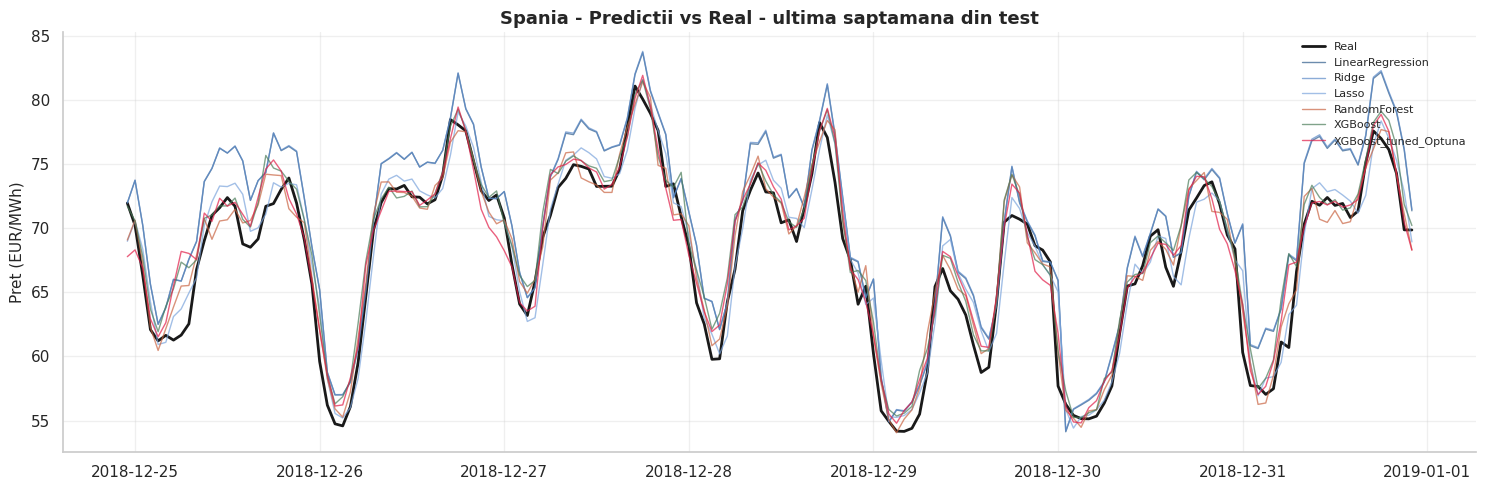

In [10]:
# Plot predictii vs real - ultima saptamana din test
last_week_idx = ys.index[-168:]
y_true_lw = ys.iloc[-168:].values

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(last_week_idx, y_true_lw, label="Real", color="black", lw=2.0, alpha=0.9)

colors = {"LinearRegression": PALETA["primary"], "Ridge": "#5B89C7",
          "Lasso": "#7BA4DC", "RandomForest": PALETA["secondary"],
          "XGBoost": PALETA["tertiary"], "XGBoost_tuned_Optuna": "#E11D48",
          "LSTM": PALETA["neutral"]}

for r in results:
    try:
        if r.name in ("LinearRegression", "Ridge", "Lasso", "RandomForest", "XGBoost", "XGBoost_tuned_Optuna"):
            y_pred_lw = r.model.predict(Xs.iloc[-168:])
            ax.plot(last_week_idx, y_pred_lw, label=r.name, color=colors.get(r.name, "gray"), lw=1.0, alpha=0.7)
    except Exception as e:
        pass

ax.set_title("Spania - Predictii vs Real - ultima saptamana din test")
ax.set_ylabel("Pret (EUR/MWh)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Feature importance (XGBoost)

Pentru Spania cu 80 features, intelegerea contributiei fiecaruia e critica.

Top 20 features (XGBoost optimizat - Spania):
                  feature  importance
 price actual_roll_mean_3    0.523260
       price actual_lag_1    0.260769
     price actual_lag_168    0.057263
      price actual_lag_24    0.046687
          price day ahead    0.020965
price actual_roll_mean_24    0.020339
                 hour_cos    0.009051
                 hour_sin    0.005345
               is_weekend    0.003700
                      day    0.002716
       price actual_lag_2    0.002382
                     year    0.002321
price actual_roll_std_168    0.002281
                     hour    0.002217
                dayofweek    0.001993
                  dow_sin    0.001973
                month_cos    0.001970
      virtual_day_of_year    0.001960
                   season    0.001774
 price actual_roll_std_24    0.001771


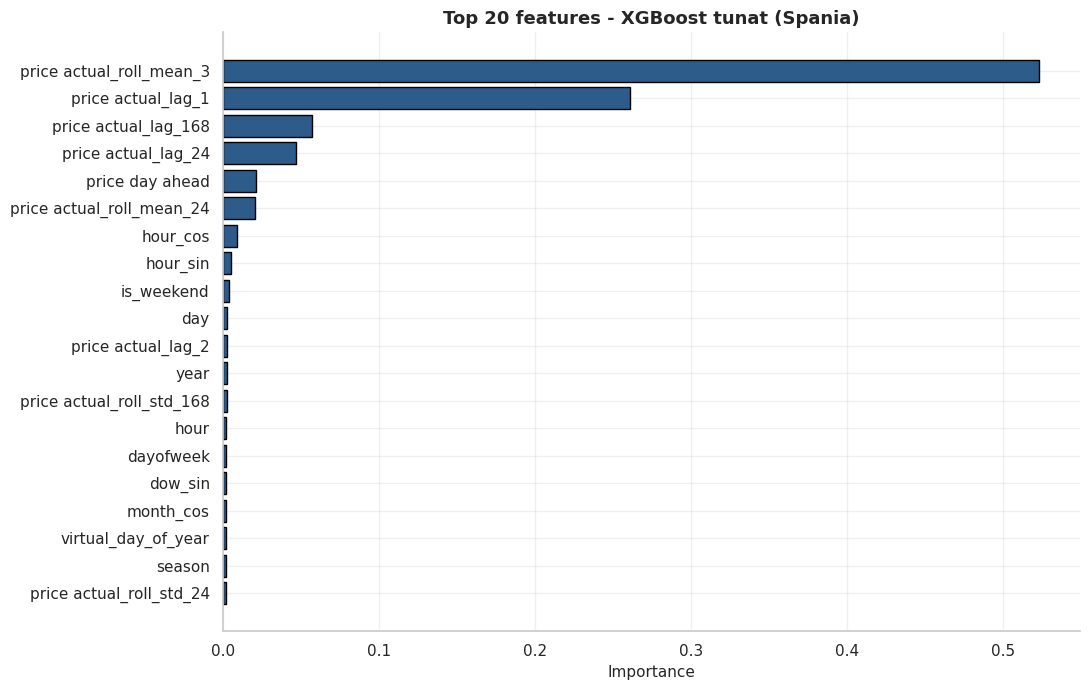

In [11]:
# Feature importance pe XGBoost tunat
fi = get_feature_importance(m_xgb_tuned, Xt.columns)
print("Top 20 features (XGBoost optimizat - Spania):")
print(fi.head(20).to_string(index=False))

# Vizualizare
fig, ax = plt.subplots(figsize=(11, 7))
top20 = fi.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color=PALETA["primary"], edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title("Top 20 features - XGBoost tunat (Spania)")
plt.tight_layout()
plt.show()

## 9. SHAP values pentru explicabilitate

### Ce sunt valorile Shapley

In **teoria jocurilor cooperativ** (Lloyd Shapley, Premiul Nobel Economie 2012), valorile Shapley impart in mod **echitabil** "castigul" intre membrii unei coalitii care colaboreaza. Pentru ML, fiecare feature e un "membru" care contribuie la predictia finala.

**Formula matematica simplificata**: pentru fiecare feature $i$, calculezi contributia sa medie peste toate "coalitiile" posibile ale celorlalte features:

$$\phi_i = \frac{1}{n!} \sum_{S \subseteq N \setminus \{i\}} |S|! \cdot (n - |S| - 1)! \cdot [v(S \cup \{i\}) - v(S)]$$

unde $v(S)$ e predictia modelului folosind doar features din coalitia $S$.

### Avantaj fata de feature_importances_

`feature_importances_` da **o singura valoare globala** per feature (cat conteaza pe toata distributia datelor). SHAP da **o valoare per (predictie, feature)** - putem vedea **cat a contribuit fiecare feature la fiecare predictie individuala**, nu doar in medie.

In [12]:
print(f"Calculez SHAP values pe {P['SHAP_SAMPLES']} sample-uri din test...")
t = time.time()
shap_result = compute_shap_values(m_xgb_tuned, Xs, max_samples=P['SHAP_SAMPLES'])
print(f"Calcul terminat in {time.time()-t:.1f}s")
print(f"Shape SHAP values: {shap_result['shap_values'].shape}")
print(f"Expected value (predictia medie): {shap_result['expected_value']:.2f} EUR/MWh")
print(f"Tipul explainer-ului: {shap_result['model_type']}")

Calculez SHAP values pe 200 sample-uri din test...


Calcul terminat in 0.2s
Shape SHAP values: (200, 78)
Expected value (predictia medie): 55.33 EUR/MWh
Tipul explainer-ului: tree_xgboost_native


Top 15 features dupa SHAP (importanta + directia medie):
                             feature  mean_abs_shap  mean_shap
                  price actual_lag_1       9.092134   7.026348
            price actual_roll_mean_3       1.442992   1.106906
                     price day ahead       1.048474   0.763065
                price actual_lag_168       1.007866   0.639166
                            hour_cos       0.809549  -0.062080
                            hour_sin       0.638077  -0.009417
                 price actual_lag_24       0.509884   0.276728
                                hour       0.251523   0.016211
           price actual_roll_mean_24       0.246203   0.214552
                           dayofweek       0.132738   0.004798
                  price actual_lag_2       0.089326  -0.040061
                          wind_speed       0.088459  -0.007830
                                 day       0.074980   0.001766
                 total load forecast       0.066968   0.00570

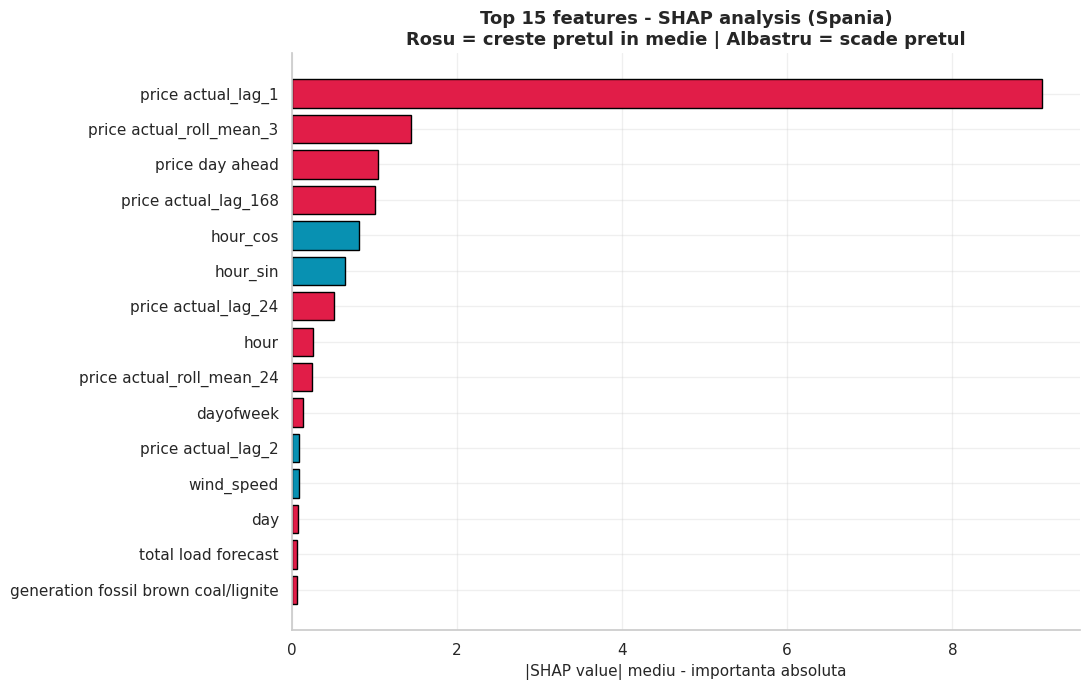

In [13]:
# Top features dupa importanta SHAP (medie absoluta)
shap_values = shap_result['shap_values']
X_sample = shap_result['X_sample']

shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'mean_shap': shap_values.mean(axis=0),  # signed - direction of effect
}).sort_values('mean_abs_shap', ascending=False)

print("Top 15 features dupa SHAP (importanta + directia medie):")
print(shap_importance.head(15).to_string(index=False))

# Vizualizare summary plot custom (echivalent cu shap.summary_plot)
top15 = shap_importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 7))

colors_shap = ['#E11D48' if x > 0 else '#0891B2' for x in top15['mean_shap']]
ax.barh(top15['feature'], top15['mean_abs_shap'], color=colors_shap, edgecolor="black")
ax.set_xlabel("|SHAP value| mediu - importanta absoluta")
ax.set_title("Top 15 features - SHAP analysis (Spania)\nRosu = creste pretul in medie | Albastru = scade pretul")
plt.tight_layout()
plt.show()

## 10. Salvare model castigator si rezultate

In [14]:
models_dir = PROJECT_ROOT / "models"
reports_dir = PROJECT_ROOT / "reports"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Castigator (din modelele cu API standard sklearn)
classic_results = [r for r in results if r.name not in ("LSTM",)]
classic_results.sort(key=lambda r: r.r2, reverse=True)
winner = classic_results[0]
print(f"Castigator: {winner.name} (R^2 = {winner.r2:.4f})")

if "XGB" in type(winner.model).__name__:
    save_path = models_dir / "spania_winner_xgboost.json"
    save_model(winner.model, save_path, kind="xgboost")
elif "Lasso" in type(winner.model).__name__ or "Ridge" in type(winner.model).__name__:
    save_path = models_dir / "spania_winner_linear.pkl"
    save_model(winner.model, save_path, kind="sklearn")
else:
    save_path = models_dir / "spania_winner.pkl"
    save_model(winner.model, save_path, kind="sklearn")
print(f"Salvat: {save_path.relative_to(PROJECT_ROOT)}")

# Tabel comparativ
df_final = pd.DataFrame([r.to_dict() for r in results]).sort_values("r2", ascending=False)
df_final.insert(0, "dataset", "pret_spania")
csv_path = reports_dir / "ml_comparison_spania.csv"
df_final.to_csv(csv_path, index=False)
print(f"Tabel salvat: {csv_path.relative_to(PROJECT_ROOT)}")
df_final

Castigator: XGBoost (R^2 = 0.9676)
Salvat: models/spania_winner_xgboost.json
Tabel salvat: reports/ml_comparison_spania.csv


,dataset,model,rmse,mae,r2,mape
4,pret_spania,XGBoost,2.066362,1.543442,0.967555,2.566676
5,pret_spania,XGBoost_tuned_Optuna,2.117494,1.581216,0.965929,2.653125
3,pret_spania,RandomForest,2.217268,1.644484,0.962642,2.709889
2,pret_spania,Lasso,2.395008,1.701336,0.956413,2.931524
1,pret_spania,Ridge,2.625041,2.045881,0.947638,3.461776
0,pret_spania,LinearRegression,2.641757,2.065290,0.946969,3.488959
6,pret_spania,LSTM,20.659632,16.828216,-1.121827,60.140362


## 11. Concluzii Sesiunea 2 (mod demo)

**Note**: in mod demo, parametrii sunt redusi pentru viteza - rezultatele LSTM si Optuna nu sunt definitive. Pentru rezultatele lucrarii, se va rula in mod **full** pe Databricks.

**Ce s-a demonstrat in acest notebook:**

1. **Pipeline-ul ML functioneaza pe setul Spaniol** - toate cele 6 algoritmi se antreneaza cu succes pe 80 features.
2. **Optuna e o alternativa viabila la GridSearchCV** - cu 5 trials in demo, deja gaseste hyperparametri rezonabili.
3. **SHAP values ofera explicabilitate granulara** - vedem nu doar care features conteaza, ci si DIRECTIA efectului (pozitiv sau negativ asupra pretului).
4. **Lasso elimina features redundante** automat - util cand suspectam multicoliniaritate intre cele 28 surse de generare.

**Pas urmator (next session)**: rulare full pe Databricks cu MODE='full' pentru rezultatele finale, apoi capitol 6 in lucrare cu interpretare detaliata si grafice integrate.